## Preprocessing and Descriptive Analysis

This notebook prepares the lyrics dataset for the text mining project.

The preprocessing pipeline includes:
- Text cleaning
- Tokenization
- Stopword removal
- Lemmatization

Additionally, a descriptive analysis of the dataset is performed to understand basic characteristics of the lyrics corpus.

In [1]:
import pandas as pd
import numpy as np
import re

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import nltk

nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/mariasuriel/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mariasuriel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### General descriptive analysis

###  Dataset information

In [3]:
df = pd.read_csv("data/final_df.csv")

df.head()

,spotify_id,name,artists,album_name,album_release_date,danceability,energy,valence,tempo,loudness,speechiness,acousticness,instrumentalness,entry_date,exit_date,days_in_top50,lyrics
0,3EaJDYHA0KnX88JvDhL9oa,Dark Red,Steve Lacy,Dark Red,2017-02-20,0.603,0.784,0.769,172.041,-4.023,0.0620,0.4460,0.000008,2023-10-18,2024-01-11,86,[Verse 1]\nSomething bad is 'bout to happen to...
1,6rjuKpPydT2SxN15TZpV7r,500lbs,Lil Tecca,TEC,2023-09-22,0.722,0.785,0.529,122.986,-5.451,0.0763,0.0942,0.000000,2023-10-18,2024-04-19,185,"[Intro]\nUh\nUh-uh, uh (Blatt)\nUh-uh, uh\nUh-..."
2,1yeB8MUNeLo9Ek1UEpsyz6,Rich Baby Daddy (feat. Sexyy Red & SZA),"Drake, Sexyy Red, SZA",For All The Dogs,2023-10-06,0.645,0.729,0.142,146.010,-4.560,0.0528,0.0377,0.000000,2023-10-18,2024-03-29,164,[Part I]\n\n[Intro: Jessica Domingo]\nIs it al...
3,0AYt6NMyyLd0rLuvr0UkMH,Slime You Out (feat. SZA),"Drake, SZA",For All The Dogs,2023-10-06,0.483,0.408,0.105,88.880,-9.243,0.0502,0.5080,0.000000,2023-10-18,2023-10-28,11,[Intro: Drake]\nI don't know\nI don't know wha...
4,5mjYQaktjmjcMKcUIcqz4s,Strangers,Kenya Grace,Strangers,2023-09-01,0.628,0.523,0.416,169.982,-8.307,0.0946,0.7010,0.002740,2023-10-18,2024-01-13,88,"[Intro]\nUh-huh, uh-huh, uh\nUh-huh, uh-huh, u..."


In [4]:
df.columns

Index(['spotify_id', 'name', 'artists', 'album_name', 'album_release_date',
       'danceability', 'energy', 'valence', 'tempo', 'loudness', 'speechiness',
       'acousticness', 'instrumentalness', 'entry_date', 'exit_date',
       'days_in_top50', 'lyrics'],
      dtype='object')

In [11]:
df.info

<bound method DataFrame.info of                  spotify_id                                     name  \
0    3EaJDYHA0KnX88JvDhL9oa                                 Dark Red   
1    6rjuKpPydT2SxN15TZpV7r                                   500lbs   
2    1yeB8MUNeLo9Ek1UEpsyz6  Rich Baby Daddy (feat. Sexyy Red & SZA)   
3    0AYt6NMyyLd0rLuvr0UkMH                Slime You Out (feat. SZA)   
4    5mjYQaktjmjcMKcUIcqz4s                                Strangers   
..                      ...                                      ...   
902  5jHozZMWbrExAFni95mvvH                            Por Esos Ojos   
903  53WWD2BBC6Jcip8wy5CniE                                   cLOUDs   
904  3D24ErT1MMmUfXWotSj2A2                                  ME JALO   
905  3x3K1RP3Zfi2qeMR8kyrNO          Sorry I'm Here For Someone Else   
906  3FjK86616FbluOfTxNK2gY            A N X I E T Y (feat. Doechii)   

                           artists                       album_name  \
0                       Steve La

### Summary statistics

In [12]:
df.describe()

,danceability,energy,valence,tempo,loudness,speechiness,acousticness,instrumentalness,days_in_top50
count,907.00000,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000
mean,0.62938,0.603307,0.471443,121.715196,-7.626901,0.107239,0.293318,0.022640,62.799338
std,0.15189,0.188182,0.236774,28.681154,4.349868,0.110104,0.283788,0.120133,117.588788
min,0.09390,0.001740,0.000010,46.718000,-54.341000,0.024300,0.000008,0.000000,1.000000
25%,0.52150,0.492000,0.288500,99.023500,-8.769000,0.037850,0.049800,0.000000,2.000000
50%,0.63600,0.624000,0.444000,120.011000,-6.708000,0.056900,0.185000,0.000000,8.000000
75%,0.74500,0.737500,0.649500,140.149500,-5.246000,0.129000,0.504500,0.000085,47.000000
max,0.97400,0.981000,0.981000,215.338000,-1.701000,0.921000,0.996000,0.995000,603.000000


### Distribution of Days in Top 50

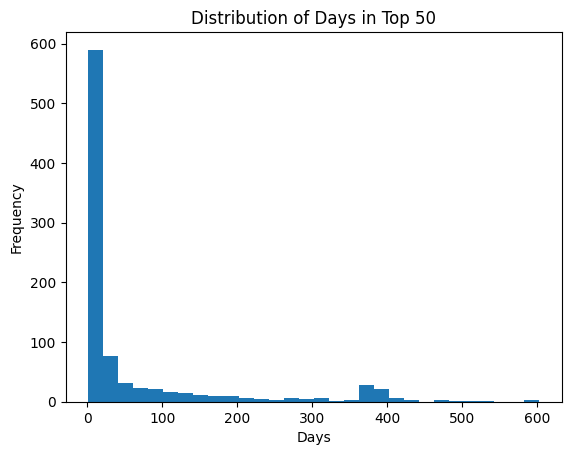

In [13]:
plt.hist(df["days_in_top50"], bins=30)
plt.title("Distribution of Days in Top 50")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

### Songs with the longest chart runs

In [18]:
df.sort_values("days_in_top50", ascending=False)[["name","artists","days_in_top50"]].head(10)

,name,artists,days_in_top50
19,I Remember Everything (feat. Kacey Musgraves),"Zach Bryan, Kacey Musgraves",603
43,See You Again (feat. Kali Uchis),"Tyler, The Creator, Kali Uchis",603
50,Dreams - 2004 Remaster,Fleetwood Mac,601
195,Lose Control,Teddy Swims,531
11,Snooze,SZA,503
24,Kill Bill,SZA,486
5,Stick Season,Noah Kahan,472
39,Sweater Weather,The Neighbourhood,472
147,Money Trees,"Kendrick Lamar, Jay Rock",463
8,Something in the Orange,Zach Bryan,442


### Songs with the shortest chart runs

In [20]:
df.sort_values("days_in_top50", ascending=True)[["name","artists","days_in_top50"]].head(10)

,name,artists,days_in_top50
453,How Did It End?,Taylor Swift,1
158,Fallin 4 U,Nicki Minaj,1
160,Let Me Calm Down (feat. J. Cole),"Nicki Minaj, J. Cole",1
403,Fever,J. Cole,1
722,Mr Chow,Lil Uzi Vert,1
721,The Rush (feat. Big Time Rush),"Lil Uzi Vert, Big Time Rush",1
720,Paars In The Mars,Lil Uzi Vert,1
719,Not An Option,Lil Uzi Vert,1
718,Chill Bae,Lil Uzi Vert,1
717,Lyft Em Up,Lil Uzi Vert,1


### Correlation heatmap

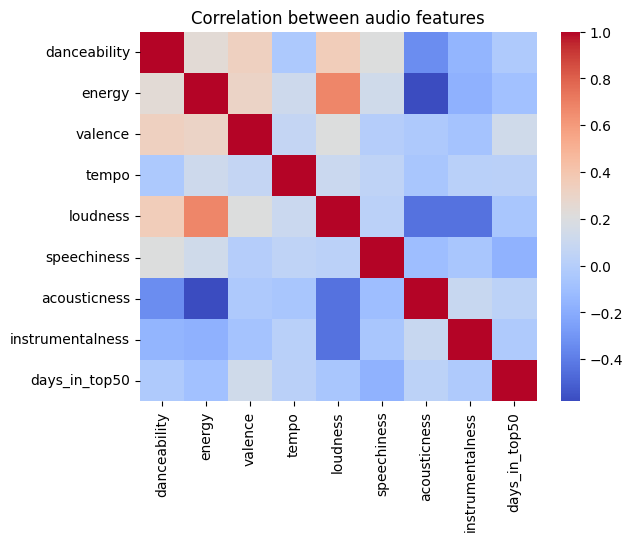

In [19]:
corr = df.select_dtypes(include=["float","int"]).corr()

sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation between audio features")
plt.show()

### Missing Values 

In [21]:
df.isna().sum()

spotify_id             0
name                   0
artists                0
album_name             4
album_release_date     4
danceability           0
energy                 0
valence                0
tempo                  0
loudness               0
speechiness            0
acousticness           0
instrumentalness       0
entry_date             0
exit_date              0
days_in_top50          0
lyrics                56
dtype: int64

In [23]:
print("Missing lyrics:", df["lyrics"].isna().sum())
print("Percentage:", round(df["lyrics"].isna().sum() / len(df) * 100, 2), "%")

Missing lyrics: 56
Percentage: 6.17 %


In [25]:
df[df["lyrics"].isna()].head()

,spotify_id,name,artists,album_name,album_release_date,danceability,energy,valence,tempo,loudness,speechiness,acousticness,instrumentalness,entry_date,exit_date,days_in_top50,lyrics
31,6wf7Yu7cxBSPrRlWeSeK0Q,What Was I Made For? [From The Motion Picture ...,Billie Eilish,What Was I Made For? [From The Motion Picture ...,2023-07-13,0.444,0.0911,0.142,78.403,-17.665,0.0307,0.9590,0.000001,2023-10-18,2024-03-16,151,NaN
50,0ofHAoxe9vBkTCp2UQIavz,Dreams - 2004 Remaster,Fleetwood Mac,Rumours (Super Deluxe),1977-02-04,0.828,0.4920,0.789,120.151,-9.744,0.0276,0.0644,0.004280,2023-10-20,2025-06-11,601,NaN
94,2QN9zL3SzXdGqqmXO68gFp,Somebody's Watching Me - Single Version,Rockwell,Somebody’s Watching Me (Sped Up),2023-09-22,0.788,0.5760,0.889,124.115,-6.996,0.0327,0.0372,0.000211,2023-11-02,2024-11-03,368,NaN
99,4so0Wek9Ig1p6CRCHuINwW,White Christmas - 1947 Version,"Bing Crosby, Ken Darby Singers, John Scott Tro...",Holiday Inn (Original Motion Picture Soundtrack),1942-01-01,0.317,0.1580,0.247,130.503,-16.485,0.0381,0.6730,0.353000,2023-11-03,2023-12-28,56,NaN
103,56xHMIfQPoe0prrSi3BGhf,Can’t Catch Me Now - from The Hunger Games: Th...,Olivia Rodrigo,Can’t Catch Me Now (from The Hunger Games: The...,2023-11-03,0.521,0.3660,0.225,141.965,-7.698,0.0340,0.8380,0.000004,2023-11-05,2023-11-12,8,NaN


In [26]:
df = df.dropna(subset=["lyrics"]).copy()

In [27]:
print("Dataset shape after removing missing lyrics:", df.shape)

Dataset shape after removing missing lyrics: (851, 17)


Songs with missing lyrics were removed from the dataset since textual analysis requires available lyrics.

### Lyrics length

In [28]:
df["lyrics_length"] = df["lyrics"].apply(len)

In [29]:
df["lyrics_length"].describe()

count     851.000000
mean     2279.692127
std      1134.399795
min       184.000000
25%      1526.000000
50%      2026.000000
75%      2728.000000
max      9825.000000
Name: lyrics_length, dtype: float64

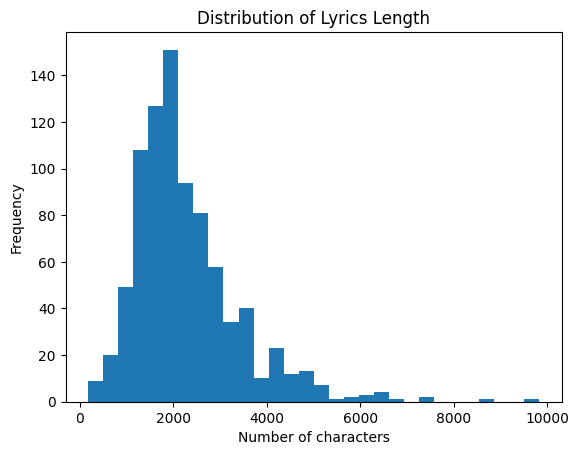

In [30]:
plt.hist(df["lyrics_length"], bins=30)
plt.title("Distribution of Lyrics Length")
plt.xlabel("Number of characters")
plt.ylabel("Frequency")
plt.show()

### Preprocessing

### Basic text cleaning

In [31]:
def clean_lyrics(text):
    text = str(text).lower()
    
    # remove section labels like [Verse], [Chorus], [Intro]
    text = re.sub(r"\[.*?\]", " ", text)
    
    # remove line breaks
    text = text.replace("\\n", " ")
    text = text.replace("\n", " ")
    
    # remove punctuation
    text = re.sub(r"[^\w\s]", " ", text)
    
    # remove numbers
    text = re.sub(r"\d+", " ", text)
    
    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [32]:
df["lyrics_clean"] = df["lyrics"].apply(clean_lyrics)
df[["lyrics", "lyrics_clean"]].head()

,lyrics,lyrics_clean
0,[Verse 1]\nSomething bad is 'bout to happen to...,something bad is bout to happen to me i don t ...
1,"[Intro]\nUh\nUh-uh, uh (Blatt)\nUh-uh, uh\nUh-...",uh uh uh uh blatt uh uh uh uh uh uh uh uh uh u...
2,[Part I]\n\n[Intro: Jessica Domingo]\nIs it al...,is it all i could be enough is it all i could ...
3,[Intro: Drake]\nI don't know\nI don't know wha...,i don t know i don t know what s wrong with yo...
4,"[Intro]\nUh-huh, uh-huh, uh\nUh-huh, uh-huh, u...",uh huh uh huh uh uh huh uh huh uh uh huh uh hu...


### Stopwords, lemmatizer and preprocessing 

In [33]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# initialize tools
STOP_WORDS = set(stopwords.words("english"))
lmtzr = WordNetLemmatizer()

def preprocess_lemma(text):
    """
    Preprocess text by:
    - tokenizing
    - removing punctuation leftovers
    - removing stopwords
    - lemmatizing
    
    Returns:
        str: processed text as a string of tokens separated by spaces
    """
    tokens = word_tokenize(text)
    
    filtered_tokens = [
        lmtzr.lemmatize(token)
        for token in tokens
        if token not in STOP_WORDS and token.isalpha()
    ]
    
    return " ".join(filtered_tokens)

In [34]:
df["lyrics_preproc"] = df["lyrics_clean"].apply(preprocess_lemma)

df[["lyrics_clean", "lyrics_preproc"]].head()

,lyrics_clean,lyrics_preproc
0,something bad is bout to happen to me i don t ...,something bad bout happen know feel coming mig...
1,uh uh uh uh blatt uh uh uh uh uh uh uh uh uh u...,uh uh uh uh blatt uh uh uh uh uh uh uh uh uh u...
2,is it all i could be enough is it all i could ...,could enough could enough bend as baow let coo...
3,i don t know i don t know what s wrong with yo...,know know wrong girl feel like need love need ...
4,uh huh uh huh uh uh huh uh huh uh uh huh uh hu...,uh huh uh huh uh uh huh uh huh uh uh huh uh hu...


### Word count

In [35]:
df["word_count"] = df["lyrics_preproc"].apply(lambda x: len(x.split()))

df["word_count"].describe()

count     851.000000
mean      231.722679
std       126.750800
min        16.000000
25%       145.000000
50%       198.000000
75%       284.500000
max      1138.000000
Name: word_count, dtype: float64

### Distribution of Lyrics Length

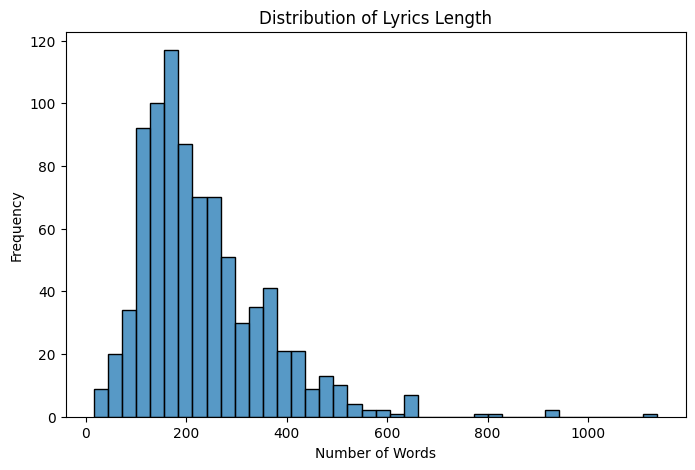

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df["word_count"], bins=40)

plt.title("Distribution of Lyrics Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

### Longest songs

In [37]:
df.sort_values("word_count", ascending=False)[["name","artists","word_count"]].head()

,name,artists,word_count
169,Lace It (with Eminem & benny blanco),"Juice WRLD, Eminem, benny blanco",1138
32,TELEFONO NUEVO,"Bad Bunny, Luar La L",927
475,Family Matters,Drake,920
270,DO IT,"Kanye West, Ty Dolla $ign",817
474,euphoria,Kendrick Lamar,775


### Shortest songs 

In [38]:
df.sort_values("word_count")[["name","artists","word_count"]].head()

,name,artists,word_count
300,Evergreen,Richy Mitch & The Coal Miners,16
386,OH LOUISIANA,Beyoncé,22
104,Now And Then,The Beatles,37
854,Opening Night,The Weeknd,37
144,Blue Christmas,Elvis Presley,37


In [39]:
total_words = df["word_count"].sum()

print("Total number of words in corpus:", total_words)

Total number of words in corpus: 197196


### Most common words in the corpus

In [51]:
from collections import Counter

all_words = " ".join(df["lyrics_preproc"]).split()

word_freq = Counter(all_words)

word_freq.most_common(40)

[('yeah', 3142),
 ('like', 3042),
 ('oh', 2236),
 ('know', 2216),
 ('got', 2091),
 ('get', 1640),
 ('love', 1608),
 ('na', 1603),
 ('nigga', 1351),
 ('baby', 1340),
 ('go', 1236),
 ('bitch', 1179),
 ('uh', 1147),
 ('one', 1137),
 ('la', 1118),
 ('let', 1058),
 ('shit', 1054),
 ('ah', 1025),
 ('fuck', 988),
 ('wan', 978),
 ('ooh', 956),
 ('say', 937),
 ('back', 924),
 ('cause', 908),
 ('time', 872),
 ('que', 839),
 ('gon', 835),
 ('want', 818),
 ('make', 794),
 ('take', 782),
 ('never', 779),
 ('tell', 774),
 ('see', 767),
 ('way', 753),
 ('come', 684),
 ('need', 680),
 ('right', 666),
 ('huh', 633),
 ('night', 628),
 ('girl', 602)]

### Word cloud

In [45]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [46]:
text = " ".join(df["lyrics_preproc"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(text)

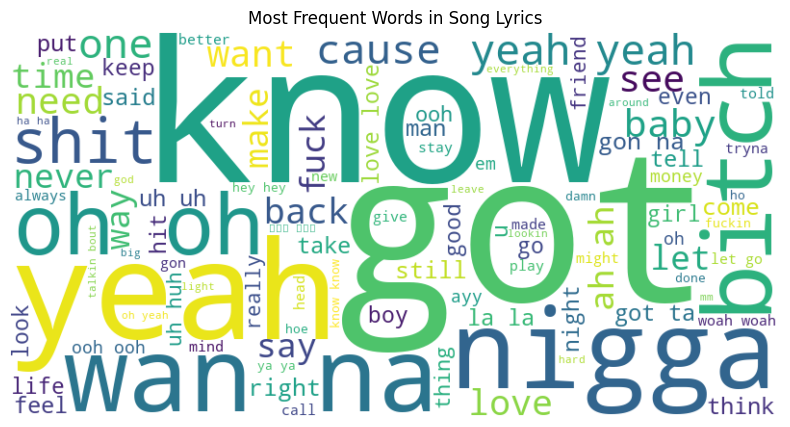

In [47]:
plt.figure(figsize=(10,5))

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

plt.title("Most Frequent Words in Song Lyrics")

plt.show()

The most frequent terms include conversational words (e.g., know, got), emotional expressions (e.g., love, baby), and musical fillers such as yeah, oh, and uh, which are typical in song lyrics; therefore, in future preprocessing steps it may be useful to define a set of custom stopwords to remove these filler terms and reduce noise in the analysis.

### Personalized Stopwords

In [52]:
from nltk.corpus import stopwords

# default stopwords
STOP_WORDS = set(stopwords.words("english"))

# custom stopwords common in song lyrics
CUSTOM_STOPWORDS = {
    "yeah", "oh", "uh", "na", "la",
    "ah", "ooh", "huh"
}

# combine both sets
STOP_WORDS = STOP_WORDS.union(CUSTOM_STOPWORDS)

In [53]:
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

lmtzr = WordNetLemmatizer()

def preprocess_lemma_v2(text):
    
    tokens = word_tokenize(text)
    
    filtered_tokens = [
        lmtzr.lemmatize(token)
        for token in tokens
        if token not in STOP_WORDS and token.isalpha()
    ]
    
    return " ".join(filtered_tokens)

In [54]:
df["lyrics_preproc_v2"] = df["lyrics_clean"].apply(preprocess_lemma_v2)

df[["lyrics_preproc", "lyrics_preproc_v2"]].head()

,lyrics_preproc,lyrics_preproc_v2
0,something bad bout happen know feel coming mig...,something bad bout happen know feel coming mig...
1,uh uh uh uh blatt uh uh uh uh uh uh uh uh uh u...,blatt livin enough ayy blunt takin puff ayy st...
2,could enough could enough bend as baow let coo...,could enough could enough bend as baow let coo...
3,know know wrong girl feel like need love need ...,know know wrong girl feel like need love need ...
4,uh huh uh huh uh uh huh uh huh uh uh huh uh hu...,always end every time meet somebody new like d...


In [55]:
from collections import Counter

all_words_v2 = " ".join(df["lyrics_preproc_v2"]).split()

word_freq_v2 = Counter(all_words_v2)

word_freq_v2.most_common(20)

[('like', 3042),
 ('know', 2216),
 ('got', 2091),
 ('get', 1640),
 ('love', 1608),
 ('nigga', 1351),
 ('baby', 1340),
 ('go', 1236),
 ('bitch', 1179),
 ('one', 1137),
 ('let', 1058),
 ('shit', 1054),
 ('fuck', 988),
 ('wan', 978),
 ('say', 937),
 ('back', 924),
 ('cause', 908),
 ('time', 872),
 ('que', 839),
 ('gon', 835)]

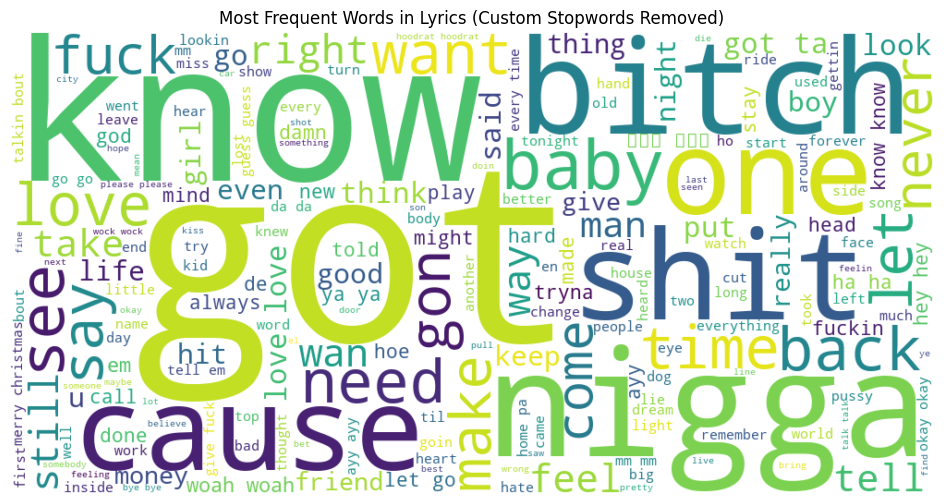

In [56]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# unir todas las letras con stopwords personalizadas removidas
text_v2 = " ".join(df["lyrics_preproc_v2"])

# crear word cloud
wordcloud_v2 = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text_v2)

# mostrar gráfico
plt.figure(figsize=(12,6))
plt.imshow(wordcloud_v2, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Lyrics (Custom Stopwords Removed)")
plt.show()